In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [2]:
df=pd.read_csv('titanic_toy.csv')

In [4]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [12]:
df.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [13]:
x=df.drop(columns=['Survived'])
y=df['Survived']

In [14]:
x.head()

,Age,Fare,Family
0,22.0,7.2500,1
1,38.0,71.2833,1
2,26.0,7.9250,0
3,35.0,53.1000,1
4,35.0,8.0500,0


In [15]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [16]:
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=0
)

In [17]:
x_train.head()

,Age,Fare,Family
140,NaN,15.2458,2
439,31.0,10.5000,0
817,31.0,37.0042,2
378,20.0,NaN,0
491,21.0,7.2500,0


In [20]:
x_train.shape,x_test.shape

((712, 3), (179, 3))

In [23]:
x_train.isnull().mean()

Age       0.198034
Fare      0.054775
Family    0.000000
dtype: float64

In [24]:
mean_age=x_train['Age'].mean()
median_age=x_train['Age'].median()

mean_fare=x_train['Fare'].mean()
median_fare=x_train['Fare'].median()

In [26]:
print(mean_age)
print(median_age)

print(mean_fare)
print(median_fare)

29.745183887915935
29.0
31.885313818722143
14.4542


In [27]:
x_train['Age_mean']=x_train['Age'].fillna(mean_age)
x_train['Age_median']=x_train['Age'].fillna(median_age)

x_train['Fare_mean']=x_train['Fare'].fillna(mean_fare)
x_train['Fare_median']=x_train['Fare'].fillna(median_fare)

In [29]:
x_train.sample(5)

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
823,27.0,12.475,1,27.0,27.0,12.475000,12.4750
526,50.0,10.500,0,50.0,50.0,10.500000,10.5000
133,29.0,NaN,1,29.0,29.0,31.885314,14.4542
441,20.0,9.500,0,20.0,20.0,9.500000,9.5000
115,21.0,7.925,0,21.0,21.0,7.925000,7.9250


In [31]:
print("Original Age Variable Variance : ",x_train['Age'].var())
print("Age Variance After mean Imputation : ",x_train['Age_mean'].var())
print("Age Variance After Median Imputation : ",x_train['Age_median'].var())

print("Original Fare Variable Variance : ",x_train['Fare'].var())
print("Fare Variance After mean Imputation : ",x_train['Fare_mean'].var())
print("Fare Variance After Median Imputation : ",x_train['Fare_median'].var())

Original Age Variable Variance :  213.7165085187575
Age Variance After mean Imputation :  171.33390978297015
Age Variance After Median Imputation :  171.42222438960792
Original Fare Variable Variance :  2574.352620663723
Fare Variance After mean Imputation :  2433.143405184278
Fare Variance After Median Imputation :  2448.8970247777565


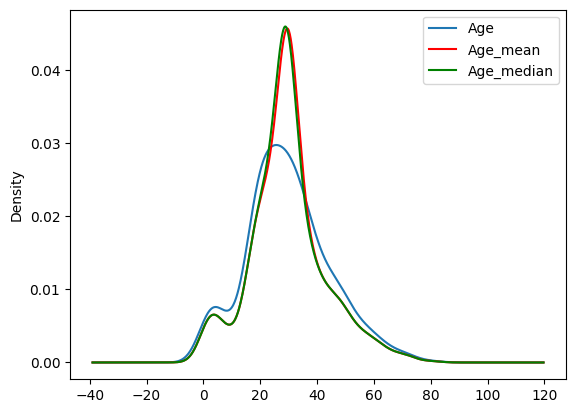

In [36]:
fig=plt.figure()
ax=fig.add_subplot(111)

## Original Variable distribution 
x_train['Age'].plot(kind='kde',ax=ax)

## Variable imputed with mean
x_train['Age_mean'].plot(kind='kde',ax=ax,color='red')

## variable imputed with meadian
x_train['Age_median'].plot(kind='kde',ax=ax,color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

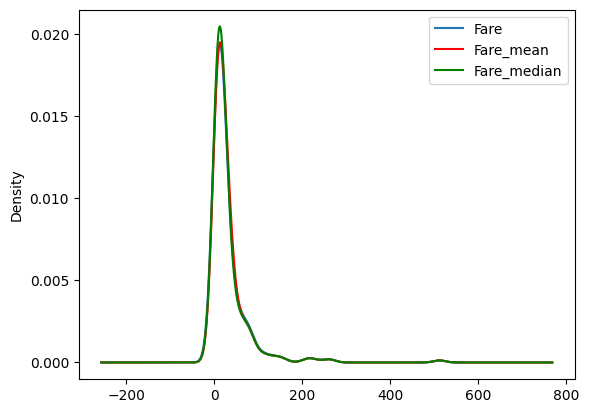

In [38]:
fig=plt.figure()
ax=fig.add_subplot(111)

## Original Variable distribution 
x_train['Fare'].plot(kind='kde',ax=ax)

## Variable imputed with mean
x_train['Fare_mean'].plot(kind='kde',ax=ax,color='red')

## variable imputed with meadian
x_train['Fare_median'].plot(kind='kde',ax=ax,color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

In [39]:
x_train.cov()

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
Age,213.716509,84.480223,-6.393469,213.716509,213.716509,79.571049,79.420930
Fare,84.480223,2574.352621,17.050423,67.493301,68.754981,2574.352621,2574.352621
Family,-6.393469,17.050423,2.770177,-5.125566,-5.121468,16.115167,16.285129
Age_mean,213.716509,67.493301,-5.125566,171.333910,171.333910,63.791137,63.670788
Age_median,213.716509,68.754981,-5.121468,171.333910,171.422224,64.983611,64.831778
Fare_mean,79.571049,2574.352621,16.115167,63.791137,64.983611,2433.143405,2433.143405
Fare_median,79.420930,2574.352621,16.285129,63.670788,64.831778,2433.143405,2448.897025


In [40]:
x_train.corr()

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
Age,1.000000,0.106334,-0.295318,1.000000,1.000000,0.103929,0.103346
Fare,0.106334,1.000000,0.198661,0.101058,0.102921,1.000000,1.000000
Family,-0.295318,0.198661,1.000000,-0.235270,-0.235021,0.196290,0.197721
Age_mean,1.000000,0.101058,-0.235270,1.000000,0.999742,0.098800,0.098295
Age_median,1.000000,0.102921,-0.235021,0.999742,1.000000,0.100620,0.100062
Fare_mean,0.103929,1.000000,0.196290,0.098800,0.100620,1.000000,0.996778
Fare_median,0.103346,1.000000,0.197721,0.098295,0.100062,0.996778,1.000000


<Axes: >

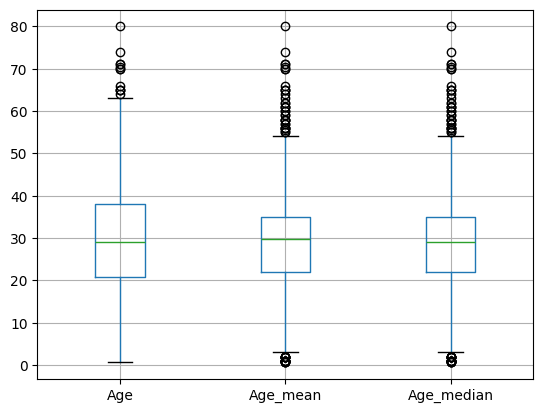

In [42]:
x_train[['Age','Age_mean','Age_median']].boxplot()

<Axes: >

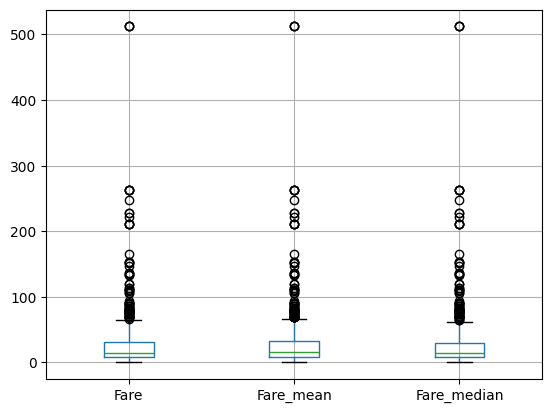

In [43]:
x_train[['Fare','Fare_mean','Fare_median']].boxplot()

## Using sklearn

In [44]:
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=0
)

In [45]:
imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')

In [46]:
trf = ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder='passthrough')

In [47]:
trf.fit(x_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer1', ...), ('imputer2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and

In [48]:
trf.named_transformers_['imputer1'].statistics_

array([29.])

In [49]:
trf.named_transformers_['imputer2'].statistics_

array([31.88531382])

In [51]:
x_train = trf.transform(x_train)
x_test = trf.transform(x_test)

In [53]:
x_train

array([[29.    , 15.2458,  2.    ],
       [31.    , 10.5   ,  0.    ],
       [31.    , 37.0042,  2.    ],
       ...,
       [29.    ,  7.7333,  0.    ],
       [36.    , 17.4   ,  1.    ],
       [60.    , 39.    ,  2.    ]], shape=(712, 3))